# Copernicus Seasonal Forecast Tools Package: Short Example

In this notebook, we give a short demonstration of an exemplary use case of the [Copernicus Seasonal Forecast Tools](https://github.com/DahyannAraya/copernicus-seasonal-forecast-tools) Package. For a more complete tutorial including the different configuration options, please refer to the [Full Walkthrough](climada_hazard_copernicus_forecast).


**Note**:
To run this tutorial, please check that you have
- installed the package (see [simple](index) or [advanced](installation) installation instructions),
- created a CDS account, API credentials, and accepted the dataset's terms and conditions (see the [CDS API setup guide](cds-api-setup)), 
- (if you eventually want to create a CLIMADA Hazard object) installed CLIMADA, see [installation](installation) instructions. 

## Define seasonal forecast parameters

In our exemplary use case, we are interested in the seasonal forecast of the heat stress index [Wet-Bulb Globe Temperature](https://doi.org/10.1016/j.softx.2022.101005) (WBGT) in Portugal. We want to use the forecasted WBGT for the summer months June, July and August 2023, where the forecast is produced in April 2023 by the DWD. We are interested in the monthly WBGT values (corresponding to the mean of the WBGT values for the specific month).

For this task, we first initialize a `SeasonalForecast` object with the corresponding parameters. Note that the initialization requires a bounding box for the geographic extent, for which we use a helper function `bounding_box_from_countries` to obtain the bounding box for Portugal (including a buffer). Note also that there are a number of technical parameters corresponding to the format of downloaded data and a forecast configuration parameter (see [Full Walkthrough](climada_hazard_copernicus_forecast) for more details).

In [1]:
from seasonal_forecast_tools import SeasonalForecast  
from seasonal_forecast_tools.utils.coordinates_utils import bounding_box_from_countries

bounding_box_POR = bounding_box_from_countries(['PRT']) # get bounding box for Portugal
forecast = SeasonalForecast(
    index_metric="WBGT", # Wet Bulb Globe Temperature
    year_list=[2023], # forecast for the year 2023
    forecast_period=["June", "August"], # forecast for months from June to August
    initiation_month=["April"], # forecast run in April
    bounds=bounding_box_POR,
    data_format="grib", # format of the downloaded data
    originating_centre="dwd", # data source
    system="21", # forecast configuration
    index_window="monthly", # monthly aggreation window of climate index
    )

## Download and process the data

Next, we run the method `download_and_process_data` to download the raw data required to calculate WBGT temperature (standard air temperature and dew point temperature, see [here](https://doi.org/10.1016/j.softx.2022.101005) for the definition), and to process and save them to a shape and format that can be used in the following. 

In [2]:
forecast.download_and_process_data();

## Compute climate index

Using the method `calculate_index`, we compute the requested climate index (WBGT) from the given raw data and aggregate to the requested time window (in our example: monthly aggregation).

In [3]:
forecast.calculate_index();

## Convert head index to a CLIMADA Hazard object

Finally, we convert and save the computed index to a CLIMADA Hazard object. 

In [4]:
forecast.save_index_to_hazard();

We can read the generated Hazard object and use it for further analysis in CLIMADA, e.g., for creating seasonal impact forecasts if we provide exposure and vulnerability components, see, e.g., [this tutorial](https://climada-python.readthedocs.io/en/latest/user-guide/0_10min_climada.html). Below, we plot the maximum monthly WGBT values for each location, where the maximum is taken over the 3 months and over 50 forecast ensemble members.

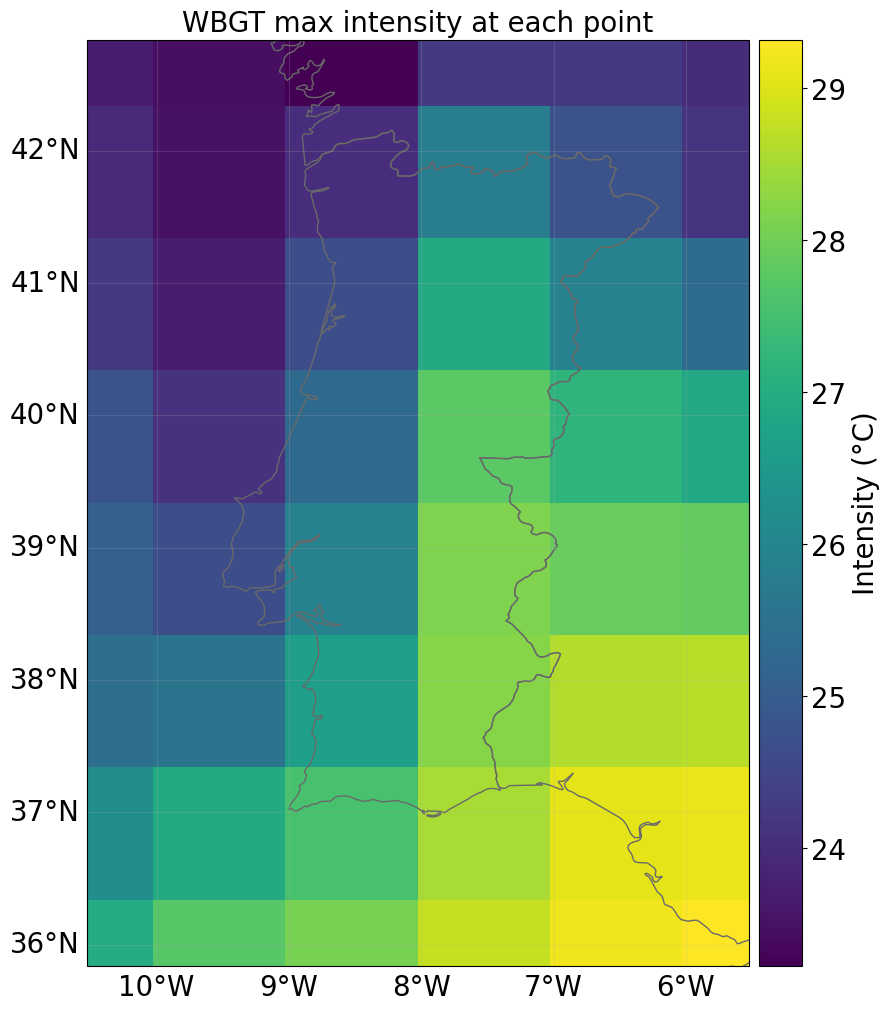

In [5]:
from climada.hazard import Hazard
path_to_hazard = forecast.get_pipeline_path(2023, "04", "hazard")
haz = Hazard.from_hdf5(path_to_hazard)
haz.plot_intensity(event=0, smooth=False);
